In [1]:
from __future__ import annotations

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

In [2]:
EXPERIMENT_NAME = "CimaIO_coretweetweighted_rts_min2_filtering"
#EXPERIMENT_NAME = "CimaIO_coretweetweighted_rts_filtering"

# Base analysis paths (defined once)
base_path = Path("..") / "output" / EXPERIMENT_NAME / "analysis"
bootstrap_dir = base_path / "bootstrap"

ci_files = sorted(bootstrap_dir.glob("*replacement_ci.txt"))
manifest = pd.DataFrame({"path": [p.resolve() for p in ci_files]})
manifest["filename"] = manifest["path"].apply(lambda p: p.name)
manifest[["dataset", "metric"]] = manifest["filename"].str.extract(
    r"^(?P<dataset>.+)_(?P<metric>ap|ndcg|auc)_replacement_ci\.txt$", flags=re.IGNORECASE
)
manifest["metric"] = manifest["metric"].str.upper()

csv_files = sorted(
    list(bootstrap_dir.glob("*_ap_replacement.csv"))
    + list(bootstrap_dir.glob("*_ndcg_replacement.csv"))
    + list(bootstrap_dir.glob("*_auc_replacement.csv"))
)

metrics = sorted(manifest["metric"].dropna().unique())
datasets = sorted(manifest["dataset"].dropna().unique())
metrics_lower = [m.lower() for m in metrics]

print(f"Analyzing: {base_path}")
print(f"Bootstrap path exists: {bootstrap_dir.exists()}")
print(f"Datasets: {datasets}")
print(f"Metrics: {metrics}")

manifest

Analyzing: ../output/CimaIO_coretweetweighted_rts_min2_filtering/analysis
Bootstrap path exists: True
Datasets: ['Honduras', 'UAE']
Metrics: ['AP', 'AUC', 'NDCG']


,path,filename,dataset,metric
0,/home/budyblack/Documents/CSIC/IIIA/PhD/Github...,Honduras_ap_replacement_ci.txt,Honduras,AP
1,/home/budyblack/Documents/CSIC/IIIA/PhD/Github...,Honduras_auc_replacement_ci.txt,Honduras,AUC
2,/home/budyblack/Documents/CSIC/IIIA/PhD/Github...,Honduras_ndcg_replacement_ci.txt,Honduras,NDCG
3,/home/budyblack/Documents/CSIC/IIIA/PhD/Github...,UAE_ap_replacement_ci.txt,UAE,AP
4,/home/budyblack/Documents/CSIC/IIIA/PhD/Github...,UAE_auc_replacement_ci.txt,UAE,AUC
5,/home/budyblack/Documents/CSIC/IIIA/PhD/Github...,UAE_ndcg_replacement_ci.txt,UAE,NDCG


In [3]:
def normalize_method(method: str) -> str:
    if method == "Co-Retweet [Linf] NoFilter":
        return "Co-Retweet"
    if method == "Co-Retweet-Weighted-12h [Linf] NoFilter":
        return "Co-Retweet-Weighted-12h"
    if method == "Lexicographic: Co-Retweet [Linf]+Co-Retweet-Weighted-12h NoFilter [Linf]":
        return "Lexic.: Co-Retweet + Co-Retweet-Weighted-12h"
    if method == "Co-Retweet min2 [Linf] NoFilter":
        return "Co-Retweet min2"
    if method == "Co-Retweet-Weighted-12h min2 [Linf] NoFilter":
        return "Co-Retweet-Weighted-12h min2"
    if method == "Lexicographic: Co-Retweet min2 [Linf]+Co-Retweet-Weighted-12h min2 NoFilter [Linf]":
        return "Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-12h min2"
    return method


def parse_ci_file(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8")
    lines = [line.rstrip() for line in text.splitlines()]

    dataset = None
    metric = None
    for line in lines:
        if line.startswith("Dataset:"):
            dataset = line.split(":", 1)[1].strip()
        if line.startswith("Metric:"):
            metric = line.split(":", 1)[1].strip().upper()

    records = []
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line and not line.startswith(("Dataset:", "Metric:", "CI level:")):
            method = normalize_method(line)
            if i + 2 < len(lines):
                mean_line = lines[i + 1].strip()
                ci_line = lines[i + 2].strip()
                mean_match = re.search(r"Mean:\s*([0-9.]+)", mean_line)
                ci_match = re.search(r"CI:\s*\[([0-9.]+),\s*([0-9.]+)\]", ci_line)
                if mean_match and ci_match:
                    mean = float(mean_match.group(1))
                    ci_low = float(ci_match.group(1))
                    ci_high = float(ci_match.group(2))
                    records.append(
                        {
                            "dataset": dataset,
                            "metric": metric,
                            "method": method,
                            "mean": mean,
                            "ci_low": ci_low,
                            "ci_high": ci_high,
                        },
                    )
            i += 3
        else:
            i += 1

    return pd.DataFrame.from_records(records)


frames = [parse_ci_file(path) for path in ci_files]
ci_df = pd.concat(frames, ignore_index=True)

# Load bootstrap samples from CSVs for permutation tests
bootstrap_samples: dict[tuple[str, str, str], np.ndarray] = {}
bootstrap_index_records = []
for path in csv_files:
    stem = path.stem
    match = re.match(r"^(?P<dataset>.+)_(?P<metric>ap|ndcg|auc)_replacement$", stem, flags=re.IGNORECASE)
    if not match:
        continue
    dataset = match.group("dataset")
    metric = match.group("metric").upper()
    df = pd.read_csv(path)
    for col in df.columns:
        method = normalize_method(col)
        values = df[col].to_numpy()
        bootstrap_samples[(dataset, metric, method)] = values
        bootstrap_index_records.append(
            {"dataset": dataset, "metric": metric, "method": method, "n": len(values)}
)

bootstrap_index = pd.DataFrame(bootstrap_index_records).drop_duplicates()

def get_samples(dataset: str, metric: str, method: str) -> np.ndarray:
    key = (dataset, metric.upper(), normalize_method(method))
    return bootstrap_samples[key]

bootstrap_index.sort_values(["dataset", "metric", "method"]).reset_index(drop=True)

,dataset,metric,method,n
0,Honduras,AP,Co-Retweet min2,1000
1,Honduras,AP,Co-Retweet-Weighted-12h min2,1000
2,Honduras,AP,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,1000
3,Honduras,AUC,Co-Retweet min2,1000
4,Honduras,AUC,Co-Retweet-Weighted-12h min2,1000
5,Honduras,AUC,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,1000
6,Honduras,NDCG,Co-Retweet min2,1000
7,Honduras,NDCG,Co-Retweet-Weighted-12h min2,1000
8,Honduras,NDCG,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,1000
9,UAE,AP,Co-Retweet min2,1000


### Bootstrap Confidence Interval

In [9]:
# Pairwise permutation (sign-flip) tests for each dataset/metric/method comparison
from itertools import combinations

def bootstrap_significance(a: np.ndarray, b: np.ndarray, num_comparisons: int = 3):
    # Total alpha
    alpha = 0.05
    # Bonferroni adjusted alpha
    adj_alpha = alpha / num_comparisons
    
    # Calculate adjusted percentiles
    lower_perc = (adj_alpha / 2) * 100
    upper_perc = 100 - lower_perc
    
    diffs = a - b
    lower_bound = np.percentile(diffs, lower_perc)
    upper_bound = np.percentile(diffs, upper_perc)
    mean_diff = np.mean(diffs)
    
    # If the adjusted interval does not contain 0, it's significant
    is_significant = lower_bound > 0 or upper_bound < 0
    
    return mean_diff, lower_bound, upper_bound, is_significant

results = []
for (dataset, metric), group in bootstrap_index.groupby(["dataset", "metric"], sort=True):
    methods = sorted(group["method"].unique())
    for m1, m2 in combinations(methods, 2):
        a = get_samples(dataset, metric, m1)
        b = get_samples(dataset, metric, m2)
        mean_diff, lower_bound, upper_bound, is_significant = bootstrap_significance(a, b, len(methods))
        results.append(
            {
                "dataset": dataset,
                "metric": metric,
                "method_a": m1,
                "method_b": m2,
                "mean_diff": mean_diff,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "is_significant": is_significant,
                "n": len(a),
            }
        )

results_df = pd.DataFrame(results)
results_df.sort_values(["dataset", "metric", "is_significant"]).reset_index(drop=True)

,dataset,metric,method_a,method_b,mean_diff,lower_bound,upper_bound,is_significant,n
0,Honduras,AP,Co-Retweet min2,Co-Retweet-Weighted-12h min2,-0.023645,-0.029385,-0.017996,True,1000
1,Honduras,AP,Co-Retweet min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,-0.013135,-0.015909,-0.010451,True,1000
2,Honduras,AP,Co-Retweet-Weighted-12h min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,0.010510,0.006458,0.015070,True,1000
3,Honduras,AUC,Co-Retweet min2,Co-Retweet-Weighted-12h min2,-0.012226,-0.016327,-0.007775,True,1000
4,Honduras,AUC,Co-Retweet min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,-0.009385,-0.012378,-0.006105,True,1000
5,Honduras,AUC,Co-Retweet-Weighted-12h min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,0.002841,0.001372,0.004499,True,1000
6,Honduras,NDCG,Co-Retweet min2,Co-Retweet-Weighted-12h min2,-0.003057,-0.004167,-0.002085,True,1000
7,Honduras,NDCG,Co-Retweet min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,-0.001392,-0.001830,-0.000952,True,1000
8,Honduras,NDCG,Co-Retweet-Weighted-12h min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,0.001665,0.000941,0.002531,True,1000
9,UAE,AP,Co-Retweet min2,Co-Retweet-Weighted-12h min2,-0.094350,-0.109298,-0.081065,True,1000


## Bootstrap CI for Paired Systems Comparison

In [5]:
import numpy as np
import pandas as pd
from itertools import combinations
from BootCI import paired_bootstrap_interval
from BootCI.Fisher_Pitman_paired_test import fpreptest

def stat_mean(pred: np.ndarray, rep: np.ndarray) -> float:
    # BootCI expects a callable with (pred, rep); rep is unused here.
    return float(np.mean(pred))

def paired_bootstrap_ci(a: np.ndarray, b: np.ndarray, alpha: float, n_iter: int) -> tuple[float, float]:
    y_dummy = np.zeros_like(a, dtype=int)
    bs = paired_bootstrap_interval.Bootstrap(a, b, y_dummy, stat=stat_mean, n_iter=n_iter)
    ci_low, ci_high = bs.get_confidence_interval(alpha, method="percentile")
    return float(ci_low), float(ci_high)

def paired_fisher_pitman_pvalue(a: np.ndarray, b: np.ndarray, n_iter: int) -> float:
    y_dummy = np.zeros_like(a, dtype=int)
    return float(fpreptest(a, b, y_dummy, stat_mean, n_iter))

alpha = 0.05 / len(methods)
n_iter = 1000

results = []
for (dataset, metric), group in bootstrap_index.groupby(["dataset", "metric"], sort=True):
    methods = sorted(group["method"].unique())
    for m1, m2 in combinations(methods, 2):
        a = get_samples(dataset, metric, m1)
        b = get_samples(dataset, metric, m2)
        if len(a) != len(b):
            min_len = min(len(a), len(b))
            a = a[:min_len]
            b = b[:min_len]
        diff_mean = float(np.mean(a - b))
        p_value = paired_fisher_pitman_pvalue(a, b, n_iter)
        ci_low, ci_high = paired_bootstrap_ci(a, b, alpha, n_iter)
        results.append(
            {
                "dataset": dataset,
                "metric": metric,
                "method_a": m1,
                "method_b": m2,
                "diff_mean": diff_mean,
                "p_value": p_value,
                "ci_low": ci_low,
                "ci_high": ci_high
            }
        )

results_df = pd.DataFrame(results)
results_df.sort_values(["dataset", "metric", "p_value"]).reset_index(drop=True)

,dataset,metric,method_a,method_b,diff_mean,p_value,ci_low,ci_high
0,Honduras,AP,Co-Retweet min2,Co-Retweet-Weighted-12h min2,-0.023645,0.001,-0.023844,-0.023443
1,Honduras,AP,Co-Retweet min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,-0.013135,0.001,-0.013226,-0.013047
2,Honduras,AP,Co-Retweet-Weighted-12h min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,0.010510,0.001,0.010363,0.010639
3,Honduras,AUC,Co-Retweet min2,Co-Retweet-Weighted-12h min2,-0.012226,0.001,-0.012377,-0.012101
4,Honduras,AUC,Co-Retweet min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,-0.009385,0.001,-0.009488,-0.009285
5,Honduras,AUC,Co-Retweet-Weighted-12h min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,0.002841,0.001,0.002788,0.002888
6,Honduras,NDCG,Co-Retweet min2,Co-Retweet-Weighted-12h min2,-0.003057,0.001,-0.003094,-0.003024
7,Honduras,NDCG,Co-Retweet min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,-0.001392,0.001,-0.001406,-0.001378
8,Honduras,NDCG,Co-Retweet-Weighted-12h min2,Lexic.: Co-Retweet min2 + Co-Retweet-Weighted-...,0.001665,0.001,0.001639,0.001689
9,UAE,AP,Co-Retweet min2,Co-Retweet-Weighted-12h min2,-0.094350,0.001,-0.094846,-0.093899


## Plot

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# 1. Build pairwise differences (A-B) from bootstrap samples
plot_data = []

# Global legend mapping
all_methods = sorted(bootstrap_index["method"].unique())
letter_map = {m: chr(ord("A") + i) for i, m in enumerate(all_methods)}
legend_text = "; ".join([f"{letter_map[m]}={m}" for m in all_methods])

for (dataset, metric), group in bootstrap_index.groupby(["dataset", "metric"]):
    methods = sorted(group["method"].unique())
    for m1, m2 in combinations(methods, 2):
        a = get_samples(dataset, metric, m1)
        b = get_samples(dataset, metric, m2)
        if len(a) != len(b):
            min_len = min(len(a), len(b))
            a = a[:min_len]
            b = b[:min_len]
        diffs = a - b
        comp_label = f"{letter_map[m1]}-{letter_map[m2]}"
        for d in diffs:
            plot_data.append(
                {
                    "Dataset": dataset,
                    "Metric": metric,
                    "Comparison": comp_label,
                    "Difference": d,
                    "method_a": m1,
                    "method_b": m2,
                }
            )

df_plot = pd.DataFrame(plot_data)

Using whiskers at percentiles: (0.8333333333333334, 99.16666666666667) for alpha=0.0167


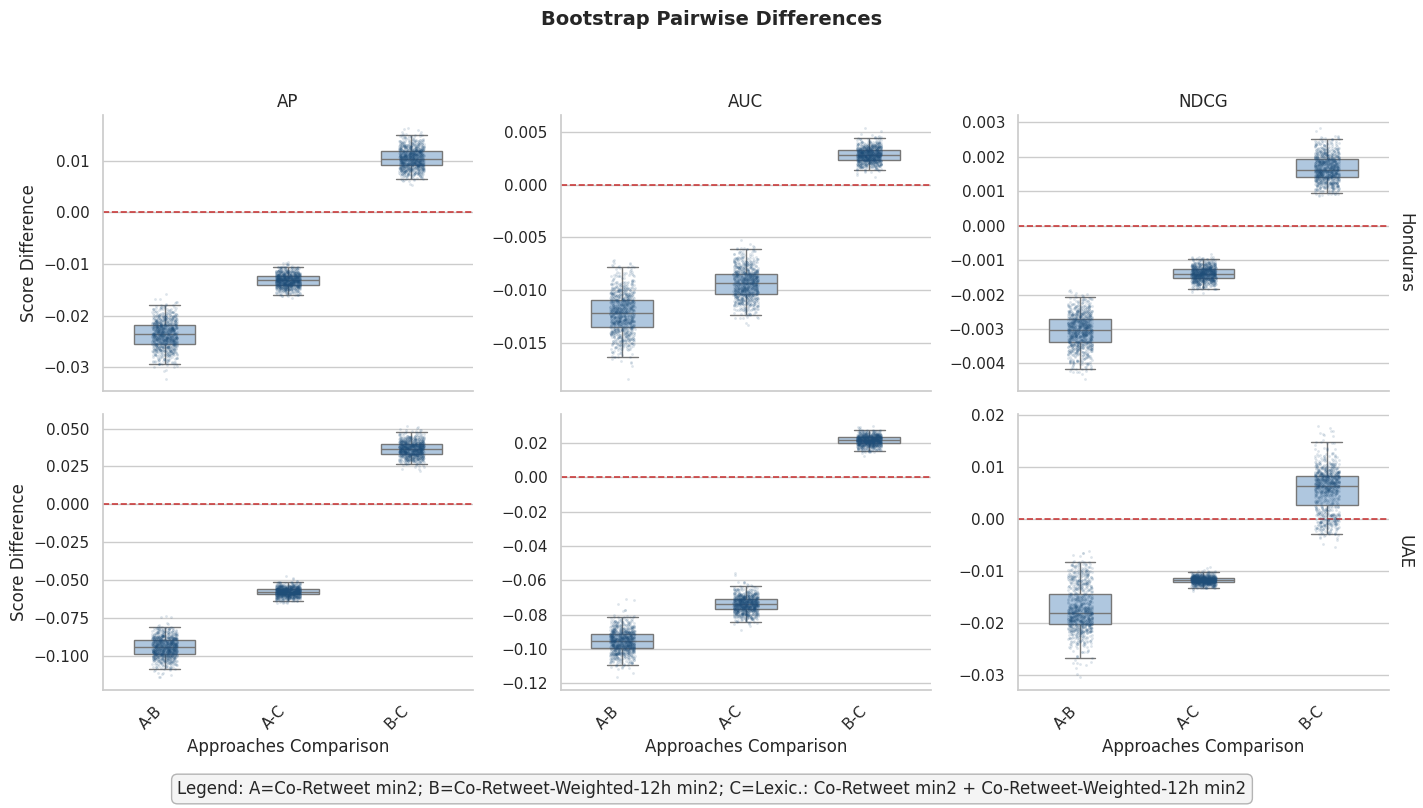

In [7]:
# Bonferroni correction for number of comparisons
per_comparison_alpha = 5 / len(methods)      # 1.667  (this is α'/1 in percent)
tail = per_comparison_alpha / 2              # 0.833
whiskers = (tail, 100 - tail)                # (0.833, 99.167)
print(f"Using whiskers at percentiles: {whiskers} for alpha={alpha:.4f}")

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the FacetGrid
g = sns.FacetGrid(
    df_plot,
    row="Dataset",
    col="Metric",
    sharey=False,
    height=4,
    aspect=1.2,
    margin_titles=True,
)

# 1. Add the Boxplot
g.map_dataframe(
    sns.boxplot,
    x="Comparison",
    y="Difference",
    color="#A7C7E7",
    fliersize=0,
    width=0.5,
    whis=whiskers
)

# 2. Add the Jittered Points
g.map_dataframe(
    sns.stripplot,
    x="Comparison",
    y="Difference",
    color="#1F4E79",
    alpha=0.15,
    jitter=True,
    size=2,
)

# 3. Zero reference line + x-label rotation
for ax in g.axes.flat:
    ax.axhline(0, color="#C62828", linewidth=1.2, linestyle="--", alpha=0.9)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("Approaches Comparison", "Score Difference")

# Title
g.fig.suptitle("Bootstrap Pairwise Differences", fontsize=14, fontweight="bold", y=0.995)

# Pretty global legend mapping at the bottom
g.fig.text(
    0.5,
    0.01,
    f"Legend: {legend_text}",
    ha="center",
    va="bottom",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#F4F4F4", edgecolor="#B0B0B0", alpha=0.95),
)

plt.tight_layout(rect=(0, 0.04, 1, 0.96))
plt.show()

In [39]:
# Store the figure in the plot directory
plot_dir = base_path / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)
# Diferentiate between rts_filtering and rts_min2_filtering in the plot filename
if "min2" in EXPERIMENT_NAME:
    plot_path = plot_dir / "bootstrap_CI_min2.png"
else:
    plot_path = plot_dir / "bootstrap_CI.png"
# Save the figure
g.savefig(plot_path, dpi=300)
print(f"Bootstrap pairwise differences plot saved to: {plot_path}")

Bootstrap pairwise differences plot saved to: ../output/CimaIO_coretweetweighted_rts_min2_filtering/analysis/plots/bootstrap_CI_min2.png
